<a href="https://colab.research.google.com/github/Abinav-70/ML/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data (1).xlsx


In [3]:
import pandas as pd

data = pd.read_excel('Lab Session Data.xlsx',sheet_name=3)
print(data.dtypes)

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

def label_encoding(data, columns):
    data = data.copy()

    encoder = LabelEncoder()

    for col in columns:
        data[col] = encoder.fit_transform(data[col].astype(str))

    return data


def one_hot_encoding(data, columns):
    data = data.copy()

    data = pd.get_dummies(data,
                          columns=columns,
                          drop_first=False)

    return data



In [5]:
categorical_cols = ["Education", "Marital_Status"]


label_df = label_encoding(data, categorical_cols)

onehot_df = one_hot_encoding(data, categorical_cols)

print("Original Shape :", data.shape)
print("Label Encoded Shape :", label_df.shape)
print("One Hot Shape :", onehot_df.shape)

Original Shape : (2240, 29)
Label Encoded Shape : (2240, 29)
One Hot Shape : (2240, 40)


In [6]:
def minkowski_distance(x, y, p):
    total = 0
    for i in range(len(x)):
        total += abs(x[i] - y[i]) ** p
    return total ** (1 / p)

A = [2, 3]
B = [5, 7]

print(minkowski_distance(A, B, 3))
print(minkowski_distance(A, B, 4))

4.497941445275415
4.284572294953817


p	Distance
1 	 13431.0
2 	 11825.004228329053
3 	 11794.975787215702
4 	 11794.036213715512
5 	 11794.001454169289
6 	 11794.000061245159
7 	 11794.00000266629
8 	 11794.000000118998
9 	 11794.00000000541
10 	 11794.000000000256


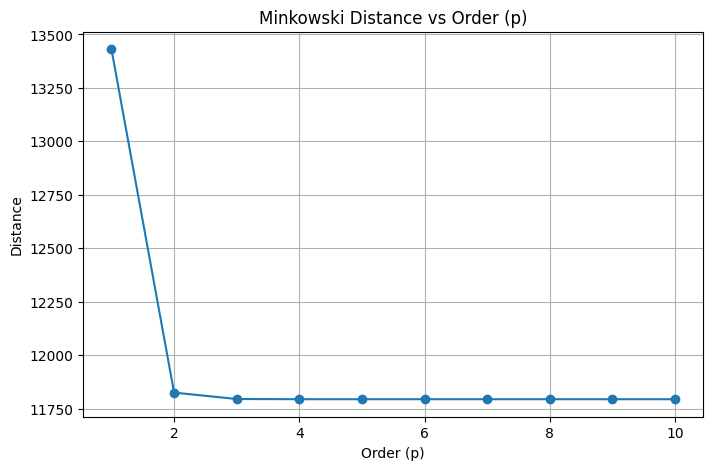

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

customer1 = numeric_df.iloc[0].drop("ID").values
customer2 = numeric_df.iloc[1].drop("ID").values

def minkowski_distance(point1, point2, p):

    distance = 0

    for i in range(len(point1)):
        distance += abs(point1[i] - point2[i]) ** p

    distance = distance ** (1 / p)

    return distance

p_values = []
distances = []

for p in range(1, 11):

    d = minkowski_distance(customer1, customer2, p)

    p_values.append(p)

    distances.append(d)

print("p\tDistance")
for p, d in zip(p_values, distances):
    print(p, "\t", d)

plt.figure(figsize=(8,5))
plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance vs Order (p)")
plt.xlabel("Order (p)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [8]:
import pandas as pd
from scipy.spatial.distance import minkowski

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

customer1 = numeric_df.iloc[0].drop("ID").values.astype(float)
customer2 = numeric_df.iloc[1].drop("ID").values.astype(float)

def minkowski_distance(point1, point2, p):

    distance = 0

    for i in range(len(point1)):
        distance += abs(point1[i] - point2[i]) ** p

    distance = distance ** (1 / p)

    return distance

print("p\tOwn Function\tSciPy Function")

for p in range(1, 11):

    own_distance = minkowski_distance(customer1, customer2, p)

    scipy_distance = minkowski(customer1, customer2, p)

    print(f"{p}\t{own_distance:.6f}\t{scipy_distance:.6f}")

p	Own Function	SciPy Function
1	13431.000000	13431.000000
2	11825.004228	11825.004228
3	11794.975787	11794.975787
4	11794.036214	11794.036214
5	11794.001454	11794.001454
6	11794.000061	11794.000061
7	11794.000003	11794.000003
8	11794.000000	11794.000000
9	11794.000000	11794.000000
10	11794.000000	11794.000000


In [9]:
import pandas as pd
import numpy as np
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

A = numeric_df.iloc[0].drop("ID").values.astype(float)
B = numeric_df.iloc[1].drop("ID").values.astype(float)

def dot_product(vector1, vector2):

    dot = 0

    for i in range(len(vector1)):
        dot += vector1[i] * vector2[i]

    return dot


def euclidean_norm(vector):

    norm = 0

    for i in range(len(vector)):
        norm += vector[i] ** 2

    norm = math.sqrt(norm)

    return norm


my_dot = dot_product(A, B)
my_norm_A = euclidean_norm(A)
my_norm_B = euclidean_norm(B)

numpy_dot = np.dot(A, B)
numpy_norm_A = np.linalg.norm(A)
numpy_norm_B = np.linalg.norm(B)

print("----------- Dot Product -----------")
print("My Function      :", my_dot)
print("NumPy dot()      :", numpy_dot)

print("\n----------- Euclidean Norm -----------")
print("Vector A")
print("My Function      :", my_norm_A)
print("NumPy norm()     :", numpy_norm_A)

print("\nVector B")
print("My Function      :", my_norm_B)
print("NumPy norm()     :", numpy_norm_B)

print("\nComparison")

if abs(my_dot - numpy_dot) < 1e-6:
    print("Dot Product : SAME")
else:
    print("Dot Product : DIFFERENT")

if abs(my_norm_A - numpy_norm_A) < 1e-6:
    print("Norm of Vector A : SAME")
else:
    print("Norm of Vector A : DIFFERENT")

if abs(my_norm_B - numpy_norm_B) < 1e-6:
    print("Norm of Vector B : SAME")
else:
    print("Norm of Vector B : DIFFERENT")

----------- Dot Product -----------
My Function      : 2698185160.0
NumPy dot()      : 2698185160.0

----------- Euclidean Norm -----------
Vector A
My Function      : 58177.442217753094
NumPy norm()     : 58177.442217753094

Vector B
My Function      : 46385.19442667024
NumPy norm()     : 46385.19442667024

Comparison
Dot Product : SAME
Norm of Vector A : SAME
Norm of Vector B : SAME


In [10]:
import pandas as pd
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

if "ID" in numeric_df.columns:
    numeric_df = numeric_df.drop("ID", axis=1)

def calculate_mean(data):

    total = 0

    for value in data:
        total += value

    mean = total / len(data)

    return mean


def calculate_variance(data):

    mean = calculate_mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    variance = variance / len(data)

    return variance


def calculate_standard_deviation(data):

    variance = calculate_variance(data)

    standard_deviation = math.sqrt(variance)

    return standard_deviation


def dataset_statistics(dataset):

    print("{:<30} {:>15} {:>15} {:>20}".format("Feature","Mean","Variance","Standard Deviation"))
    print("-"*85)

    for column in dataset.columns:

        data = dataset[column].values.astype(float)

        mean = calculate_mean(data)

        variance = calculate_variance(data)

        standard_deviation = calculate_standard_deviation(data)

        print("{:<30} {:>15.4f} {:>15.4f} {:>20.4f}".format(column,mean,variance,standard_deviation))


dataset_statistics(numeric_df)

Feature                                   Mean        Variance   Standard Deviation
-------------------------------------------------------------------------------------
Year_Birth                           1968.8058        143.5538              11.9814
Income                                     nan             nan                  nan
Kidhome                                 0.4442          0.2897               0.5383
Teenhome                                0.5062          0.2964               0.5444
Recency                                49.1094        838.4492              28.9560
MntWines                              303.9357     113247.2253             336.5223
MntFruits                              26.3022       1581.2198              39.7646
MntMeatProducts                       166.9500      50924.6850             225.6650
MntFishProducts                        37.5254       2982.9931              54.6168
MntSweetProducts                       27.0629       1703.3188            

In [11]:
import pandas as pd
import numpy as np
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

if "ID" in numeric_df.columns:
    numeric_df = numeric_df.drop("ID", axis=1)

def calculate_mean(data):

    total = 0

    for value in data:
        total += value

    return total / len(data)


def calculate_variance(data):

    mean = calculate_mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)


def calculate_standard_deviation(data):

    variance = calculate_variance(data)

    return math.sqrt(variance)


print("{:<30}{:>15}{:>15}{:>15}{:>15}".format(
    "Feature",
    "My Mean",
    "NumPy Mean",
    "My Std",
    "NumPy Std"
))

print("-"*90)

for column in numeric_df.columns:

    data = numeric_df[column].values.astype(float)

    my_mean = calculate_mean(data)

    numpy_mean = np.mean(data)

    my_std = calculate_standard_deviation(data)

    numpy_std = np.std(data)

    print("{:<30}{:>15.4f}{:>15.4f}{:>15.4f}{:>15.4f}".format(
        column,
        my_mean,
        numpy_mean,
        my_std,
        numpy_std
    ))

Feature                               My Mean     NumPy Mean         My Std      NumPy Std
------------------------------------------------------------------------------------------
Year_Birth                          1968.8058      1968.8058        11.9814        11.9814
Income                                    nan            nan            nan            nan
Kidhome                                0.4442         0.4442         0.5383         0.5383
Teenhome                               0.5062         0.5062         0.5444         0.5444
Recency                               49.1094        49.1094        28.9560        28.9560
MntWines                             303.9357       303.9357       336.5223       336.5223
MntFruits                             26.3022        26.3022        39.7646        39.7646
MntMeatProducts                      166.9500       166.9500       225.6650       225.6650
MntFishProducts                       37.5254        37.5254        54.6168        54.6168

Mean = 52247.25135379061
Variance = 633397830.1872728

Histogram Counts
[1654  554    7    0    0    0    0    0    0    1]

Bin Edges
[  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]


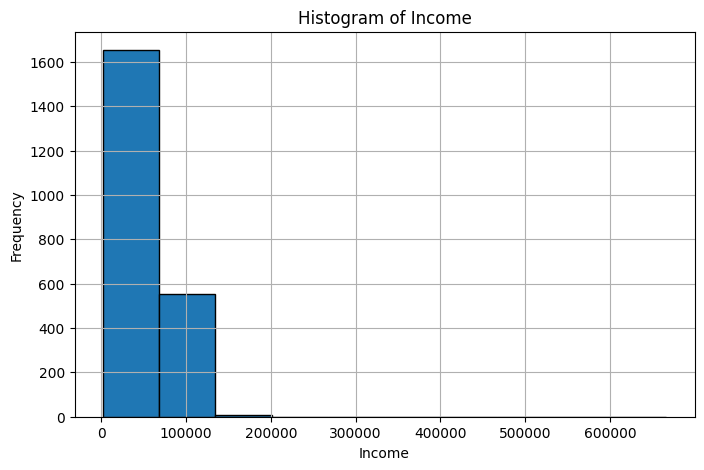

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

feature = df["Income"].dropna()

mean = np.mean(feature)

variance = np.var(feature)

print("Mean =", mean)
print("Variance =", variance)

counts, bins = np.histogram(feature, bins=10)

print("\nHistogram Counts")
print(counts)

print("\nBin Edges")
print(bins)

plt.figure(figsize=(8,5))

plt.hist(feature, bins=10, edgecolor="black")

plt.title("Histogram of Income")

plt.xlabel("Income")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()